Generowanie danych (na podstawie pierszego laboratorium)

In [21]:
import numpy as np

observations = 1000

xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))

inputs = np.column_stack((xs,zs))

noise = np.random.uniform(low=-1, high=1, size=(observations,1))
#targets = 2*xs - 3*zs + 5 + noise

targets = xs**2 + zs**2 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)

Laboratorium 2

2.19.0
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4508.4531  
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2590.0471 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1998.6591
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1935.6310 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1814.0410 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1759.6299 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1798.6099 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1711.6179 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1736.4180 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1798.0988 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1821.1664 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1758.6583 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1789.7292 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1748.9753 
Epoch 15

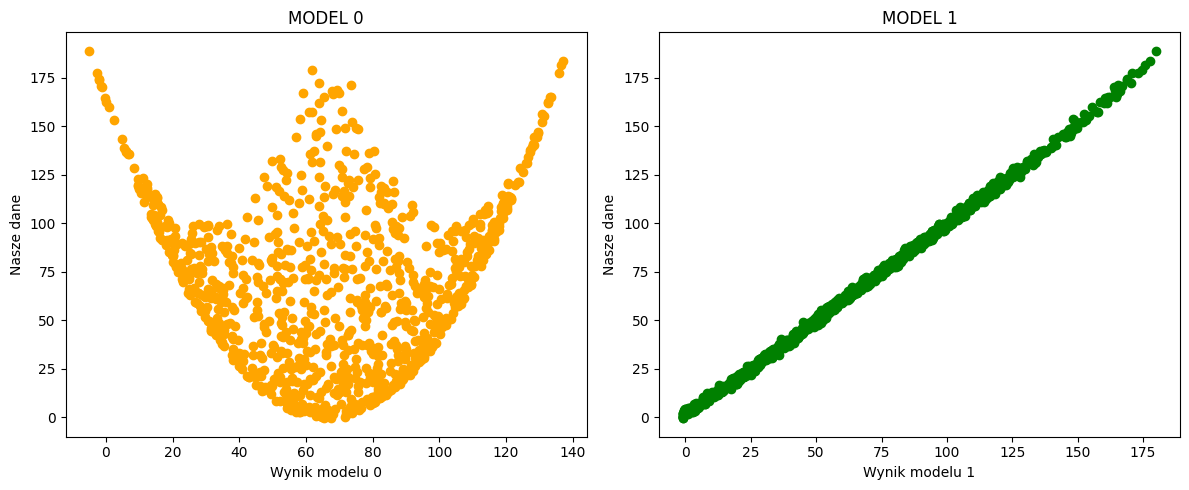

In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print(tf.__version__)

training_data = np.load("TF_dataset.npz")
input_size = 2
output_size = 1


model_0 = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size)
])
model_0.compile(optimizer='sgd', loss='mean_squared_error')
model_0.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=1)
model_0.layers[0].get_weights()
model_0.predict_on_batch(training_data['inputs']).round(1)


model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(output_size)
    ])


model_1.compile(optimizer='adamw', loss='huber')
model_1.fit(training_data['inputs'], training_data['targets'], epochs=200, verbose=1)
model_1.layers[0].get_weights()


fig, (wykres1, wykres2) = plt.subplots(1, 2, figsize=(12, 5))

wynik_model_0 = np.squeeze(model_0.predict_on_batch(training_data['inputs']))
wynik_model_1 = np.squeeze(model_1.predict_on_batch(training_data['inputs']))
nasze_dane = np.squeeze(training_data['targets'])

wykres1.scatter(wynik_model_0,nasze_dane, color = 'orange')
wykres1.set_xlabel('Wynik modelu 0')
wykres1.set_ylabel('Nasze dane')
wykres1.set_title('MODEL 0')


wykres2.scatter(wynik_model_1,nasze_dane, color = 'green')
wykres2.set_xlabel('Wynik modelu 1')
wykres2.set_ylabel('Nasze dane')
wykres2.set_title('MODEL 1')

plt.tight_layout()
plt.show()